In [21]:
!pip install openpyxl

In [25]:
!pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [13]:
!pip install numpy pandas scikit-learn

In [3]:
name="John"
age=20
print(name)
print(age)
import os
print(os.getcwd())

John
20
C:\Users\Ms-Echo


In [4]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
# Matrix as 4D  DATASET  FOR 5 DIFFERENT CARS
# Simple loading data from Excel cars

df =pd.read_excel('Desktop/car.xlsx')
print ("---1. Original dataset loaded from Excel ---")
print(df)
print("\n")

---1. Original dataset loaded from Excel ---
   Engine  Horsepower  Weight_lbs  Highway_MPG
0     1.6         120        2800           35
1     2.0         160        3100           30
2     3.0         250        3600           24
3     4.0         300        4000           18
4     5.0         420        4500           14




In [5]:
# Centering the data ( Calculating the mean of each column and subtracting it)
mean_centered_data=df -df.mean()

# Dividing the covariance matrix
covariance_matrix=np.cov(mean_centered_data.T, ddof=0)
print(" 4*4 covariance matrix after using Σ = (1 / N)XᵀX")
cov_df=pd.DataFrame(covariance_matrix, index=df.columns, columns=df.columns)
print(cov_df)
print("\n")

 4*4 covariance matrix after using Σ = (1 / N)XᵀX
               Engine  Horsepower  Weight_lbs  Highway_MPG
Engine         1.5776       132.4       764.0       -9.504
Horsepower   132.4000     11280.0     64400.0     -794.000
Weight_lbs   764.0000     64400.0    372000.0    -4640.000
Highway_MPG   -9.5040      -794.0     -4640.0       58.560




In [11]:
print("--- Calculate Eigenvalues and Eigenvectors---")
eigenvalues, eigenvectors= np.linalg.eig(covariance_matrix)
np.set_printoptions(precision=4, suppress=True) # Reduces to 4 decimal places
real_eigenvalues=eigenvalues.real #Omit the J's
real_eigenvectors=eigenvectors.real
print(real_eigenvalues)
print(real_eigenvectors)

--- Calculate Eigenvalues and Eigenvectors---
[383212.0407    128.0589      0.0001      0.038 ]
[[ 0.002  -0.0007 -0.8836 -0.4683]
 [ 0.1706 -0.9828 -0.0321  0.0628]
 [ 0.9853  0.1693  0.0132 -0.0209]
 [-0.0123 -0.0736  0.467  -0.8811]]


In [19]:
print("Sorting the variances from the highest to the lowest---")
sorted_indices =np.argsort(eigenvalues)[::-1]

#Sorting the arrays
eigenvalues=eigenvalues[sorted_indices]
eigenvectors=eigenvectors[:,sorted_indices]

#Converting to real numbers
real_eigenvalues=eigenvalues.real
real_eigenvectors=eigenvectors.real

print("---Sorted Eigenvalues λ1, λ2, λ3 λ4 from largest to smallest to be PC1, PC2, PC3, PC4---")
print(real_eigenvalues)
print("\n")
print("---Creating data frame and Sorted Eigenvectors---")
eigenvectors_df=pd.DataFrame(real_eigenvectors, index=df.columns, columns= ['PC1', 'PC2', 'PC3','PC4'])
print(eigenvectors_df)


Sorting the variances from the highest to the lowest---
---Sorted Eigenvalues λ1, λ2, λ3 λ4 from largest to smallest to be PC1, PC2, PC3, PC4---
[383212.0407    128.0589      0.038       0.0001]


---Creating data frame and Sorted Eigenvectors---
                  PC1       PC2       PC3       PC4
Engine       0.002024 -0.000723 -0.468308 -0.883562
Horsepower   0.170624 -0.982812  0.062764 -0.032071
Weight_lbs   0.985258  0.169284 -0.020894  0.013192
Highway_MPG -0.012285 -0.073641 -0.881085  0.467028


In [18]:
#Multiply with sorted eigenvectors from previous cell
pca_features_correct= np.dot (mean_centered_data, real_eigenvectors)
# Projecting the Data into the new principal components (PCA Analysis)
df_pca_correct = pd.DataFrame(pca_features_correct, columns=['PC1', 'PC2', 'PC3', 'PC4'])

print("---Final PCA Transformed data---")
print(df_pca_correct.round(4))


---Final PCA Transformed data---
        PC1      PC2     PC3     PC4
0 -810.5229  -8.4558 -0.2483  0.0025
1 -508.0585   3.3848  0.2123 -0.0113
2    0.0022   0.0148  0.2324  0.0126
3  402.7122  19.0289 -0.1687  0.0001
4  915.8670 -13.9727 -0.0278 -0.0041


In [31]:
print("---Calculatingthe total sum of thesorted eigenvalues---")
total_variance=np.sum(real_eigenvalues)
print("\n")
print("---Dividing each eigenvalue by the total sum---")
explained_variance_ratio=real_eigenvalues /total_variance
print("---Explained Variance ratio per PC---")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC {i+1}: {ratio*100:.2f}%" )

---Calculatingthe total sum of thesorted eigenvalues---


---Dividing each eigenvalue by the total sum---
---Explained Variance ratio per PC---
PC 1: 99.97%
PC 2: 0.03%
PC 3: 0.00%
PC 4: 0.00%


---Creating the scatter plot---
---Add labels to know which car is which---
---Graph Styling---
--- Showing the plot---


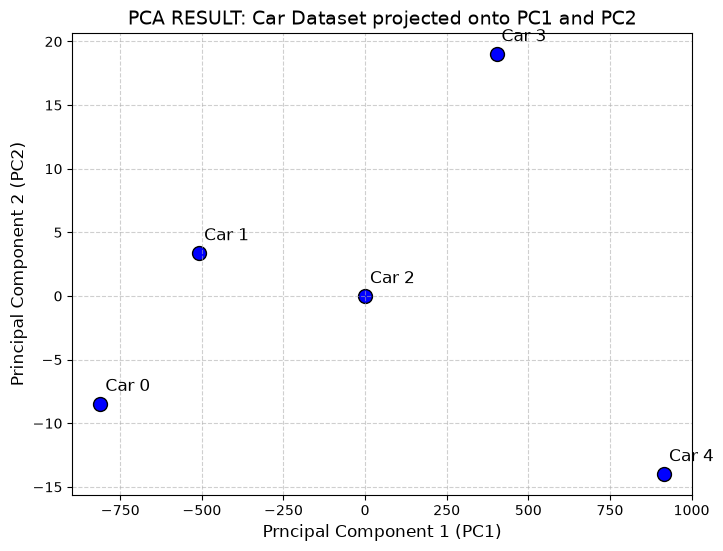

In [44]:
import matplotlib.pyplot as plt
print("---Creating the scatter plot---")
plt.figure(figsize=(8,6))
plt.scatter(df_pca_correct['PC1'], df_pca_correct['PC2'], color ='blue', edgecolor='k', s=100)

print("---Add labels to know which car is which---")
for index, row in df_pca_correct.iterrows():
    plt.text(row['PC1'] +15, row['PC2']+ 1, f"Car {index}", fontsize=12 ) 

print("---Graph Styling---")      
plt.title('PCA RESULT: Car Dataset projected onto PC1 and PC2', fontsize=14)
plt.xlabel('Prncipal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
print("--- Showing the plot---")

plt.show()           